# OMA Based Data Exploration

This notebook/script explores the dataset, focusing on features such as relative abundance, prevalence, etc.

Tutorial used: `https://bioconductor.org/books/release/OMA/pages/wrangling.html`
`https://bioconductor.org/books/release/OMA/pages/quality_control.html`

### Library Import

In [1]:
suppressPackageStartupMessages({

    ########### main libraries ###########
    library(SummarizedExperiment)
    library(TreeSummarizedExperiment)
    library(mia)
    library(miaViz) # mia visualizatioon
    library(vegan) # ecol stats?
    library(tidySingleCellExperiment)
    
    ########### data manipulation tools ###########
    library(tidyverse)
    
    ########### visualization libraries ###########   
    library(ggpubr)
    library(pheatmap)
    library(readr)
    library(RColorBrewer)
    library(colorspace)
    library(cowplot)
    library(grid)
    library(patchwork)
    library(gridExtra)
    library(ggrepel)
    library(ggpubr)
    library(ggthemes)
    library(RColorBrewer)
    library(patchwork)
    library(cowplot)
    library(scater)

    library(knitr)
    
    ########### resource management tools ###########
    # library(tictoc)

    ################ notes ####################
    ### loaded by tidyverse
    # library(ggplot2)
    # library(tidyr)
    # library(dplyr)
    # library(readr)
    # library(stringr)
})


warnLevel <- getOption('warn')
options(warn = -1)



### Arguments Piped in with R script Conversion

In [2]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [3]:
TAXA_DIR <- file.path(PROJECT_DIR, "taxonomy_assignment")
tse_rds_file <- file.path(TAXA_DIR, paste0(PROJECT_NAME, ".ASV_with_taxa.TSE.rds"))


In [4]:
# read rds file
tse <- readRDS(tse_rds_file)


In [5]:
# tse

### Make Output Directory

In [6]:
# make file output directory if it doesn't already exist
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
ABUND_DIV_DIR <-  file.path(ANALYSIS_DIR, "abund_div")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_ABUND_DIV_DIR <- file.path(FIG_DIR, "abund_div")
dir.create(ANALYSIS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(ABUND_DIV_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_ABUND_DIV_DIR, recursive = TRUE, showWarnings = FALSE)

REPORT_TABLE_DIR <- file.path(PROJECT_DIR, "report_tables")
SUMMARY_TABLE_DIR <- file.path(PROJECT_DIR, "summary_tables") # more extensive tables not for the report go here
dir.create(REPORT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(SUMMARY_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

### Set Global Parameters

In [7]:
population_levels <- unique(colData(tse)$population_group)

In [8]:
# Dynamically assign colors to values in population_group
population_levels <- unique(colData(tse)$population_group)

population_colors <- setNames(
    grDevices::hcl.colors(
        length(population_levels),
        palette = "Dark 3"
    ),
    population_levels
)

population_colors

BF        EU 
"#E16A86" "#00AD9A"

### mia library check

In [9]:
# has mia useuable taxonomy?
checkTaxonomy(tse)

[1] TRUE

In [10]:
taxonomyRanks(tse)

[1] "Kingdom" "Phylum"  "Class"   "Order"   "Family"  "Genus"

In [11]:
# rowData(tse)[, taxonomyRanks(tse)]

In [12]:
getTaxonomyLabels(tse) |> head()

# note: does not match tutorial

[1] "e5d80e368534833f89790dddf7064358"   "6415b3db426daec918b055048ef228ff"  
[3] "f69c9987c8697d3a60d760d251c88f79"   "f966fcbc558ce15a073c7d21f8f68341"  
[5] "e5d80e368534833f89790dddf7064358_1" "e5d80e368534833f89790dddf7064358_2"

In [13]:
getUnique(tse, rank = "Phylum") |> head()

[1] "Bacteroidota"    "Bacillota"       "Actinomycetota"  "Pseudomonadota" 
[5] "Patescibacteria" "Spirochaetota"

In [14]:
# test mia functions for later

# mapTaxonomy(tse, taxa = "Bacteria")

# couldnt find Escherichia as in the tutorial, check if it exists
# grep(
#     "Escher",
#     rowData(tse)$Genus,
#     value = TRUE
# )

# test mapTaxonomy 
# mapTaxonomy(tse, taxa = "Escherichia-Shigella")


# tse_sub <- tse[1:5, ]
# tse_sub

# tse_sub <- subsetByLeaf(tse_sub, rowLeaf = rownames(tse_sub))
# tse_sub

### Data Splitting

In [15]:
# Agglomerate to genus
tse_genus <- agglomerateByRank(
    tse,
    rank = "Genus",
    update.tree = FALSE
)

tse_genus

# A SingleCellExperiment-tibble abstraction: 29 × 27
# Features=163 | Cells=29 | Assays=counts
   .cell group run_id    population_group age_years sex    reported_ethnicity
   <chr> <chr> <chr>     <chr>                <dbl> <chr>  <chr>             
 1 10BF  BF    ERR011058 BF                       6 female black african     
 2 10EU  EU    ERR011059 EU                       5 male   caucasian         
 3 11BF  BF    ERR011060 BF                       5 male   black african     
 4 11EU  EU    ERR011061 EU                       5 male   caucasian         
 5 12BF  BF    ERR011062 BF                       6 male   black african     
 6 12EU  EU    ERR011063 EU                       6 male   caucasian         
 7 13BF  BF    ERR011064 BF                       6 male   black african     
 8 13EU  EU    ERR011065 EU                       5 male   caucasian         
 9 15BF  BF    ERR011066 BF                       6 male   black african     
10 16BF  BF    ERR011067 BF                    

In [16]:
# Agglomerate to phyla
tse_phyla <- agglomerateByRank(
    tse,
    rank = "Phylum",
    update.tree = FALSE
)

tse_phyla

# A SingleCellExperiment-tibble abstraction: 29 × 27
# Features=10 | Cells=29 | Assays=counts
   .cell group run_id    population_group age_years sex    reported_ethnicity
   <chr> <chr> <chr>     <chr>                <dbl> <chr>  <chr>             
 1 10BF  BF    ERR011058 BF                       6 female black african     
 2 10EU  EU    ERR011059 EU                       5 male   caucasian         
 3 11BF  BF    ERR011060 BF                       5 male   black african     
 4 11EU  EU    ERR011061 EU                       5 male   caucasian         
 5 12BF  BF    ERR011062 BF                       6 male   black african     
 6 12EU  EU    ERR011063 EU                       6 male   caucasian         
 7 13BF  BF    ERR011064 BF                       6 male   black african     
 8 13EU  EU    ERR011065 EU                       5 male   caucasian         
 9 15BF  BF    ERR011066 BF                       6 male   black african     
10 16BF  BF    ERR011067 BF                     

In [17]:
# nrow(tse_genus)
# rownames(tse_genus)[1:10]

In [18]:
colData(tse)

DataFrame with 29 rows and 26 columns
           group      run_id population_group age_years         sex
     <character> <character>      <character> <numeric> <character>
10BF          BF   ERR011058               BF         6      female
10EU          EU   ERR011059               EU         5        male
11BF          BF   ERR011060               BF         5        male
11EU          EU   ERR011061               EU         5        male
12BF          BF   ERR011062               BF         6        male
...          ...         ...              ...       ...         ...
6EU           EU   ERR011082               EU         6        male
7BF           BF   ERR011083               BF         6        male
8BF           BF   ERR011084               BF         6        male
8EU           EU   ERR011085               EU         5        male
9BF           BF   ERR011086               BF         6        male
     reported_ethnicity     antibiotic_history      delivery_mode
            

In [19]:

# Split data based on sample type
tse_list <- splitOn(tse_genus, by = "samples", group = "group")
tse_list

List of length 2
names(2): BF EU

In [20]:
##### Genus #### 

# Split data based on sample type
tse_list <- splitOn(tse_genus, by = "samples", group = "group")
tse_list
# Loop over the list of TreeSEs, and get top features for each
top_taxa <- sapply(tse_list, getTop) # getTop is coming from mia

# need to add this to match tutorial output -- swapping name for coldata from id to taxa 
genus <- rowData(tse_list[[1]])$Genus
names(genus) <- rownames(tse_list[[1]])

top_taxa_genus <- top_taxa
top_taxa_genus[] <- genus[top_taxa]

top_taxa_genus



List of length 2
names(2): BF EU

BF,EU
Segatella,Faecalibacterium
Bifidobacterium,Bacteroides
Leyella,Bifidobacterium
Faecalibacterium,Agathobacter
Streptococcus,Gemmiger


In [21]:
##### Phylum #### 

# Split data based on sample type
tse_list <- splitOn(tse_phyla, by = "samples", group = "group")
tse_list
# Loop over the list of TreeSEs, and get top features for each
top_taxa_phyla <- sapply(tse_list, getTop) # getTop is coming from mia

# need to add this to match tutorial output -- swapping name for coldata from id to taxa 
phyla <- rowData(tse_list[[1]])$Phylum
names(phyla) <- rownames(tse_list[[1]])

top_taxa_phyla_names <- top_taxa_phyla
top_taxa_phyla_names[] <- phyla[top_taxa_phyla]

top_taxa_phyla_names


List of length 2
names(2): BF EU

BF,EU
Bacteroidota,Bacillota
Bacillota,Bacteroidota
Actinomycetota,Pseudomonadota
Pseudomonadota,Actinomycetota
Patescibacteria,Thermodesulfobacteriota


In [22]:
# Melt with tidySCE to get total read counts

tse %>%
    join_features(
        features = rownames(tse),
        shape = "long"
    ) %>%
    group_by(.cell) %>%
    mutate(total_counts = sum(.abundance_counts)) %>%
    group_by(group) %>%
    summarise(
        total_counts = mean(total_counts)
    )

tidySingleCellExperiment says: join_features produces duplicate cell names to accomadate the long data format. For this reason, a data frame is returned for independent data analysis. Assay feature abundance is appended as .abundance_counts.



group,total_counts
<chr>,<dbl>
BF,12732.21
EU,14076.07


### Plot CLR Abundances per Sample

In [23]:
all_samples <- colnames(tse)

sample_colors <- setNames(
    scales::hue_pal()(length(all_samples)),
    all_samples
)

In [24]:
sample_colors

10BF      10EU      11BF      11EU      12BF      12EU      13BF      13EU 
"#F8766D" "#EF7F48" "#E48800" "#D69100" "#C69900" "#B4A000" "#9EA700" "#83AD00" 
     15BF      16BF      17BF      17EU      18EU      19EU       1EU      20EU 
"#60B200" "#19B700" "#00BB48" "#00BE6B" "#00C088" "#00C1A2" "#00C0BA" "#00BECF" 
     21EU       2BF       2EU       3BF       3EU       4BF       5EU       6BF 
"#00B9E1" "#00B3F1" "#00ABFD" "#46A0FF" "#8794FF" "#B086FF" "#CE79FF" "#E46DF6" 
      6EU       7BF       8BF       8EU       9BF 
"#F365E6" "#FC61D4" "#FF62BE" "#FF67A6" "#FE6E8B"

In [25]:
all_samples

[1] "10BF" "10EU" "11BF" "11EU" "12BF" "12EU" "13BF" "13EU" "15BF" "16BF"
[11] "17BF" "17EU" "18EU" "19EU" "1EU"  "20EU" "21EU" "2BF"  "2EU"  "3BF" 
[21] "3EU"  "4BF"  "5EU"  "6BF"  "6EU"  "7BF"  "8BF"  "8EU"  "9BF"

In [26]:
# get max y for both plots 

clr_abund_plot_data <- tse %>%
    # filter(group == "BF") %>%
    transformAssay(
        method = "clr",
        pseudocount = TRUE
    ) %>%
    join_features(
        features = rownames(.),
        shape = "long"
    ) |> mutate(.cell = factor(.cell, levels = all_samples))

y_max <- max(clr_abund_plot_data$.abundance_clr, na.rm = TRUE) * 1.1



# get the median abundance for both plots 

overall_median <- median(
    clr_abund_plot_data$.abundance_clr,
    na.rm = TRUE
)


A pseudocount of 1 was applied.

tidySingleCellExperiment says: join_features produces duplicate cell names to accomadate the long data format. For this reason, a data frame is returned for independent data analysis. Assay feature abundance is appended as .abundance_counts and .abundance_clr.



In [27]:
# set color palette 

bf_samples <- colnames(tse)[colData(tse)$group == "BF"]
eu_samples <- colnames(tse)[colData(tse)$group == "EU"]

all_colors <- scales::hue_pal()(length(c(bf_samples, eu_samples)))

bf_colors <- setNames(
    all_colors[seq_along(bf_samples)],
    bf_samples
)

eu_colors <- setNames(
    all_colors[length(bf_samples) + seq_along(eu_samples)],
    eu_samples
)

In [28]:
options(repr.plot.width = 10, repr.plot.height = 6)



p1 <- tse %>%
    filter(group == "BF") %>%
    transformAssay(
        method = "clr",
        pseudocount = TRUE
    ) %>%
    join_features(
        features = rownames(.),
        shape = "long"
    ) %>%
    mutate(.cell = factor(.cell, levels = all_samples)) %>%
    ggplot(
        aes(
            x = .cell,
            y = .abundance_clr,
            fill = .cell
        )
    ) +
    geom_violin(trim = FALSE) +
  # geom_boxplot(width = 0.12, outlier.shape = NA) +
    coord_cartesian(ylim = c(NA, y_max)) +
    theme_minimal(base_size = 17) + 
    theme(
        legend.position = "none",
        plot.title = element_text(hjust = 0.5, face = "bold")
    ) +
      labs(
        title = "CLR-Transformed Abundance Distributions\n Across Burkina Faso Samples",
        x = "BF Sample",
        y = "CLR-transformed abundance"
    ) + 
    geom_hline(
        yintercept = overall_median,
        linetype = "dashed",
        linewidth = 0.5
    )  + scale_fill_manual(values = bf_colors)

A pseudocount of 1 was applied.

tidySingleCellExperiment says: join_features produces duplicate cell names to accomadate the long data format. For this reason, a data frame is returned for independent data analysis. Assay feature abundance is appended as .abundance_counts and .abundance_clr.



In [29]:
options(repr.plot.width = 10, repr.plot.height = 6)





p2 <- tse %>%
    filter(group == "EU") %>%
    transformAssay(
        method = "clr",
        pseudocount = TRUE
    ) %>%
    join_features(
        features = rownames(.),
        shape = "long"
    ) %>%
    mutate(.cell = factor(.cell, levels = all_samples)) %>%
    ggplot(
        aes(
            x = .cell,
            y = .abundance_clr,
            fill = .cell
        )
    ) +
    geom_violin(trim = FALSE) +
  # geom_boxplot(width = 0.12, outlier.shape = NA) +
    theme_minimal(base_size = 17) + 
    coord_cartesian(ylim = c(NA, y_max)) +
theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5, face = "bold")
) +
      labs(
        title = "CLR-Transformed Abundance Distributions\n Across European Samples",
        x = "EU Sample",
        y = "CLR-transformed abundance"
    ) + 
    geom_hline(
        yintercept = overall_median,
        linetype = "dashed",
        linewidth = 0.5
    ) + scale_fill_manual(values = eu_colors)

A pseudocount of 1 was applied.

tidySingleCellExperiment says: join_features produces duplicate cell names to accomadate the long data format. For this reason, a data frame is returned for independent data analysis. Assay feature abundance is appended as .abundance_counts and .abundance_clr.



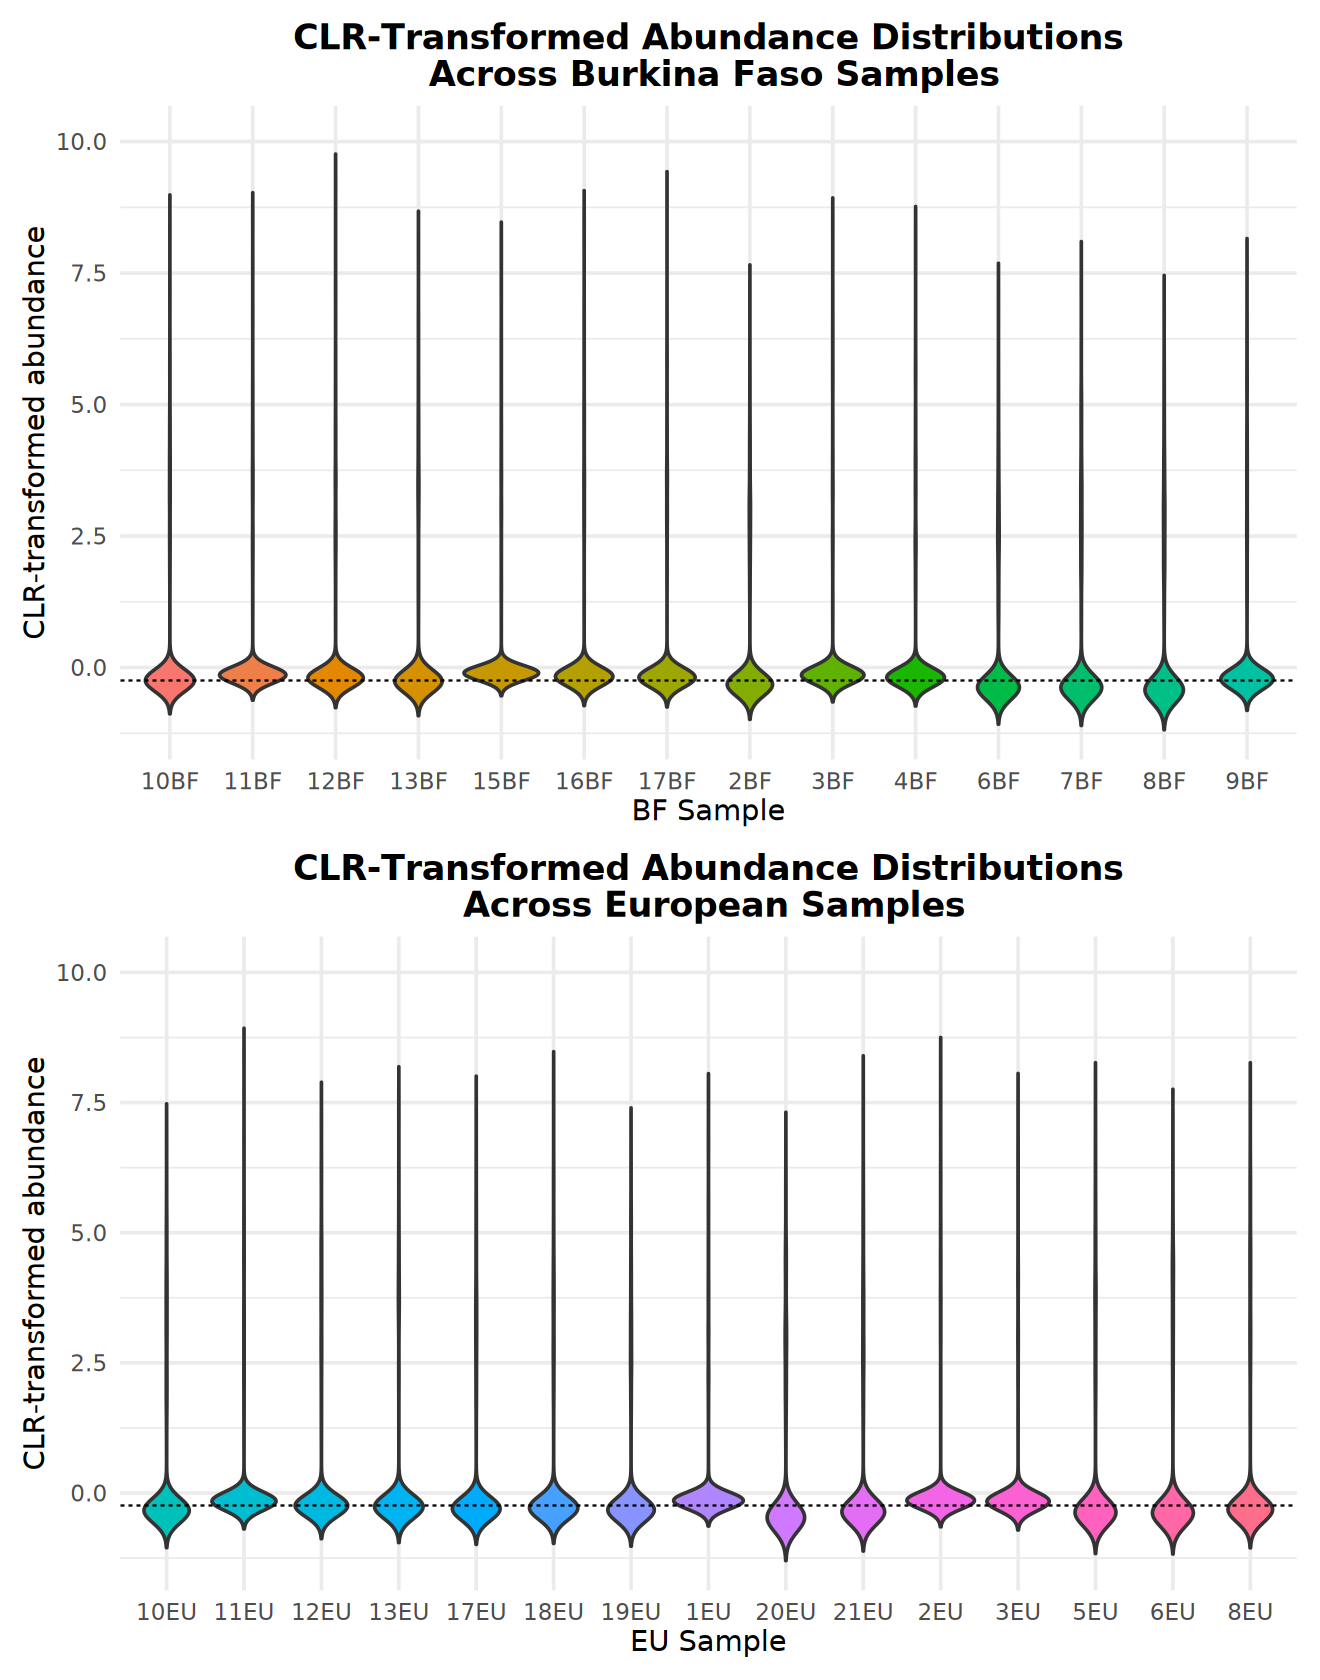

In [30]:
options(repr.plot.width = 11, repr.plot.height = 14)
pA <- p1 / p2
pA

In [31]:
ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', 'clr_abundances_per_sample.png'),
    plot = pA,
    width = 12,
    height = 14,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', 'clr_abundances_per_sample.pdf'),
    plot = pA,
    width = 11,
    height = 14,
    units = "in",
    bg = "white"
)

### Get Summary Counts

In [32]:
sum1 <- summary(tse, assay.type = "counts")
sum1$features   |>  knitr::kable(
        caption = "Summary of Overall Read Counts per ASV",
        digits = 2
    ) 
sum1$samples  |>  knitr::kable(
        caption = "Summary of Overall Read Counts per Sample",
        digits = 2
    ) 



Table: Summary of Overall Read Counts per ASV

| total| singletons| per_sample_avg|
|-----:|----------:|--------------:|
|  1402|          0|          98.31|



Table: Summary of Overall Read Counts per Sample

| total_counts| min_counts| max_counts| median_counts| mean_counts| stdev_counts|
|------------:|----------:|----------:|-------------:|-----------:|------------:|
|       389392|       7864|      20394|         12527|    13427.31|      3340.98|

In [33]:
write.table(
    sum1$features,
    file = paste0(REPORT_TABLE_DIR, '/', PROJECT_NAME, '.asv_count_summary.tsv'),
    sep = "\t",
    quote = FALSE,
    row.names = FALSE
)

write.table(
    sum1$samples, 
    file = paste0(REPORT_TABLE_DIR, '/', PROJECT_NAME, '.sample_count_summary.tsv'),
    sep = "\t",
    quote = FALSE,
    row.names = FALSE
)

### More Abundance Summary Data

In [34]:
df_summ_dom <- summarizeDominance(tse, rank = "Genus") # The summarizeDominance returns an overview in a tibble. It contains dominant taxa in a column named *name* and its abundance in the data set.
df_summ_dom

dominant_taxa,n,rel_freq
<chr>,<int>,<dbl>
Segatella,12,0.41379310
Faecalibacterium,8,0.27586207
Bacteroides,5,0.17241379
Bifidobacterium,2,0.06896552
Agathobacter,1,0.03448276
Haemophilus,1,0.03448276


In [35]:
# Explore Unique Taxa
# uniq <- getUnique(tse, rank = "Phylum")
# uniq

# uniq <- getUnique(tse, rank = "Genus")
# uniq

In [36]:
# prev <- getPrevalent(tse, rank = "Genus", prevalence = 0.2, detection = 0)
# prev |> head()

# prev <- getPrevalent(tse, rank = "Phylum", prevalence = 0.2, detection = 0)
# prev |> head()


In [37]:
# Pick the top features (here, asv)
top_features <- getTop(tse, method = "median", top = 10)
top_features

[1] "b30cb75cf4d704f6ba084fcddb169670" "6415b3db426daec918b055048ef228ff"
 [3] "61a92dcd231be67525e0066d8d70b227" "f966fcbc558ce15a073c7d21f8f68341"
 [5] "31a47236757c5a479b94cb00ddc22d31" "c8dd8499ed99ca114a47c99741069b51"
 [7] "a3160b01d9b88c4be339a6794e3aa0f8" "a9ea6cf718e6191d555ca98af320f07b"
 [9] "e5d80e368534833f89790dddf7064358" "f69c9987c8697d3a60d760d251c88f79"

In [38]:
# Calculate and add total counts to colData
tse_percellqc <- addPerCellQC(tse)




In [39]:

head(colData(tse))

DataFrame with 6 rows and 26 columns
           group      run_id population_group age_years         sex
     <character> <character>      <character> <numeric> <character>
10BF          BF   ERR011058               BF         6      female
10EU          EU   ERR011059               EU         5        male
11BF          BF   ERR011060               BF         5        male
11EU          EU   ERR011061               EU         5        male
12BF          BF   ERR011062               BF         6        male
12EU          EU   ERR011063               EU         6        male
     reported_ethnicity     antibiotic_history      delivery_mode
            <character>            <character>        <character>
10BF      black african             none known natural childbirth
10EU          caucasian more than 6 months s.. natural childbirth
11BF      black african             none known natural childbirth
11EU          caucasian more than 6 months s.. natural childbirth
12BF      black african

In [40]:
head(colData(tse_percellqc)$location          )

[1] "Burkina Faso:Boulkiemde province,Boulpon"
[2] "Italy:Toscany, Florence"                 
[3] "Burkina Faso:Boulkiemde province,Boulpon"
[4] "Italy:Toscany, Florence"                 
[5] "Burkina Faso:Boulkiemde province,Boulpon"
[6] "Italy:Toscany, Florence"

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


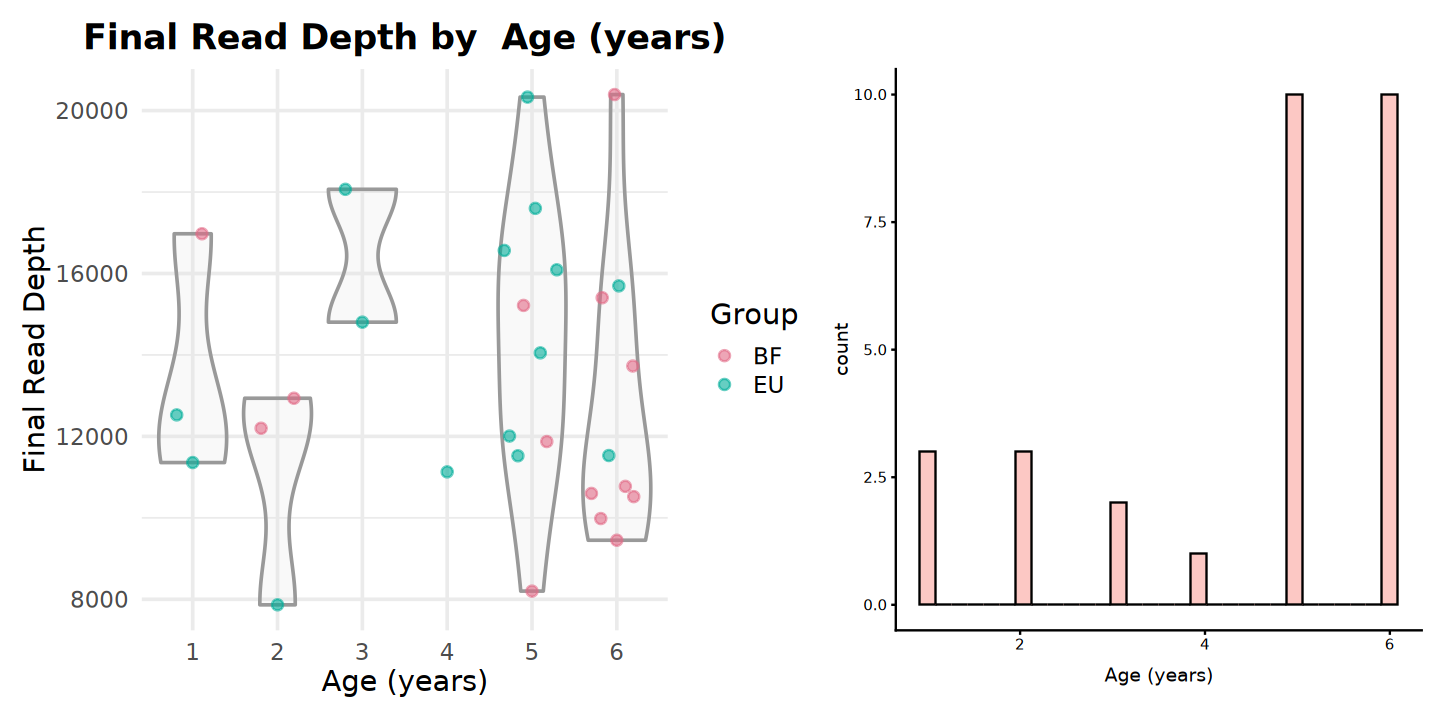

In [41]:
options(repr.plot.width = 12, repr.plot.height = 6)


make_plotColData_Violin <- function(tse1, xVar, yVar, colorVar, pointSize, 
                                    baseSize1, title1, xLabel1, yLabel1, colorLabel1, popCols ){
    # shorten selected category labels
    colData(tse1)[[xVar]] <- dplyr::recode(
        as.character(colData(tse1)[[xVar]]),
        "more than 6 months since last use" = "6 months+ since last",
        "vegeterian diet (derived from sorghum, millet, black eyed pea)" = "vegeterian diet", 
        "Burkina Faso:Boulkiemde province,Boulpon" = "Burkina Faso", 
        "Italy:Toscany, Florence" = "Italy"
    )

    pB <- plotColData(
        tse1,
        x = xVar,
        y = yVar,
        colour_by = colorVar
    )
    
    # pB$layers[[2]]$aes_params$size <- pointSize 

    # Find point layers created by plotColData -- doestn always make the same number of layers, so need dynamic
    point_layers <- which(
        sapply(pB$layers, function(x) inherits(x$geom, "GeomPoint")) # get rid of plotcoldata point size
    )

    pB <- pB +
        theme_minimal(base_size = baseSize1) +
        labs(
            title = title1,
            x = xLabel1,
            y = yLabel1,
            colour = colorLabel1
        ) +
        scale_colour_manual(
            values = popCols
        ) +
        theme(
            plot.title = element_text(
                hjust = 0.5,
                face = "bold"
            ),
            legend.position = "right"
        )

return(pB)

        
    return (pB)
}


p2 <- plotHistogram(
    tse,
    col.var = "final_read_depth"
) +
    theme_minimal(base_size = 17) +
    labs(
        title = "Distribution of\nFinal Read Depth",
        x = "Final read depth",
        y = "Number of samples"
    ) +
    theme(
        plot.title = element_text(
            hjust = 0.5,
            face = "bold"
        )
    )


# checkVariables <- c("age_years", "reported_ethnicity", "antibiotic_history",  "clinical_status", 
#                     "location", "diet_description")
# checkVariables_lab <- c("Age (years)", "Reported Ethnicity", "Antibiotic History",  "Clinical Status", 
#                     "Location", "Diet Description")




# viol_plots <- list()

# for (i in seq_along(checkVariables)) {
#     viol_plots[[i]] <- make_plotColData_Violin(
#             tse1 = tse,
#             xVar = checkVariables[i],
#             yVar = "final_read_depth",
#             colorVar = "population_group",
#             pointSize = 5,
#             baseSize1 = 17,
#             title1 = paste("Final Read Depth by ", checkVariables_lab[i]),
#             xLabel1 = checkVariables_lab[i],
#             yLabel1 = "Final Read Depth",
#             colorLabel1 = "Group"
#         )
# }



p1 <- make_plotColData_Violin(
            tse1 = tse,
            xVar = "age_years",
            yVar = "final_read_depth",
            colorVar = "population_group",
            pointSize = 5,
            baseSize1 = 17,
            title1 = paste("Final Read Depth by ", "Age (years)"),
            xLabel1 = "Age (years)",
            yLabel1 = "Final Read Depth",
            colorLabel1 = "Group", 
            popCols = population_colors
        )
        

# pV <- patchwork::wrap_plots(
#     viol_plots,
#     ncol = 2
# )

# pV

p2 <- plotHistogram(tse, col.var = "age_years") +
    labs(x = "Age (years)")
p1 + p2

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


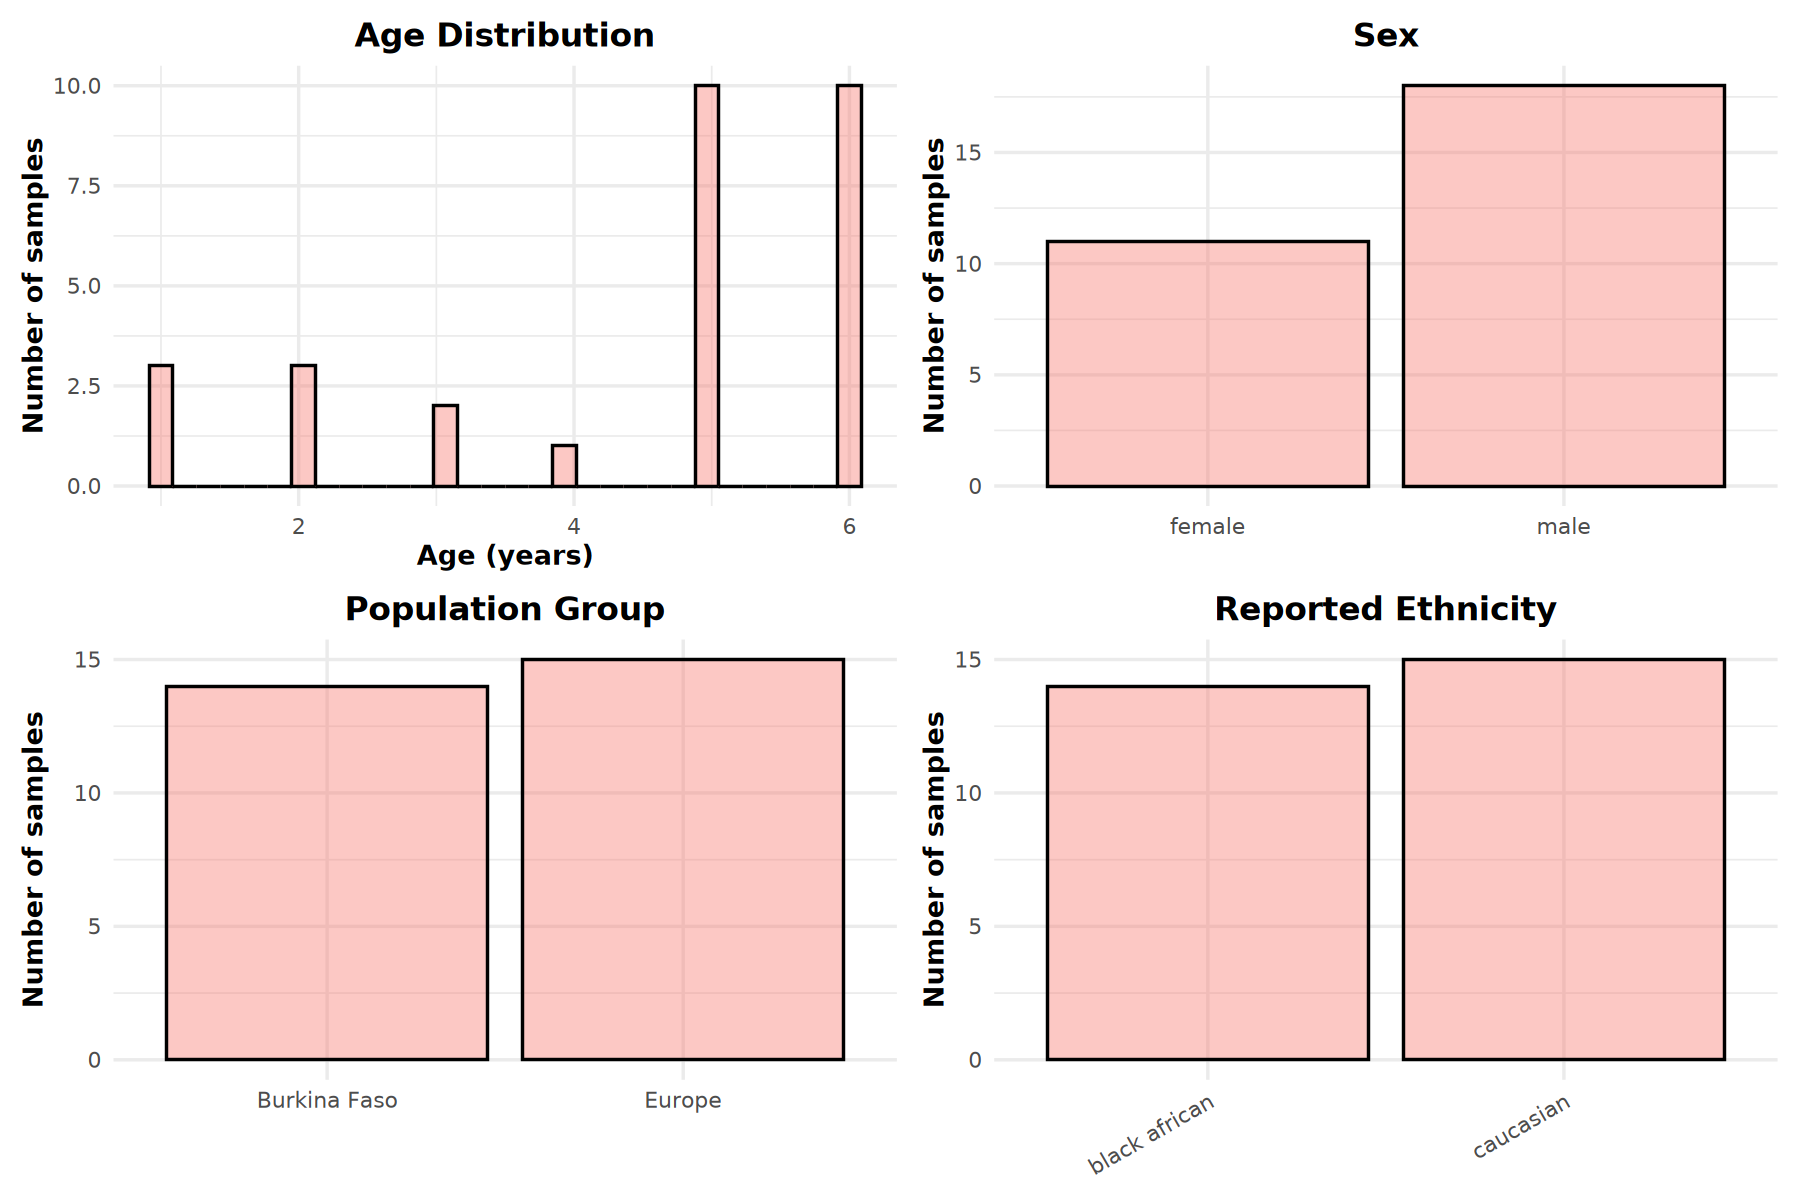

In [42]:
options(repr.plot.width = 15, repr.plot.height = 10)

plot_theme <- theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(
            hjust = 0.5,
            face = "bold"
        ),
        axis.title = element_text(face = "bold")
    )

p1 <- plotHistogram(
    tse,
    col.var = "age_years"
) +
    labs(
        title = "Age Distribution",
        x = "Age (years)",
        y = "Number of samples"
    ) +
    plot_theme

p2 <- plotBarplot(
    tse,
    col.var = "sex"
) +
    labs(
        title = "Sex",
        x = NULL,
        y = "Number of samples"
    ) +
    plot_theme

p3 <- plotBarplot(
    tse,
    col.var = "population_group"
) +
    labs(
        title = "Population Group",
        x = NULL,
        y = "Number of samples"
    ) +
    scale_x_discrete(
        labels = c(
            "BF" = "Burkina Faso",
            "EU" = "Europe"
        )
    ) +
    plot_theme

p4 <- plotBarplot(
    tse,
    col.var = "reported_ethnicity"
) +
    labs(
        title = "Reported Ethnicity",
        x = NULL,
        y = "Number of samples"
    ) +
    scale_x_discrete(
        labels = function(x) stringr::str_wrap(x, width = 15)
    ) +
    plot_theme +
    theme(
        axis.text.x = element_text(
            angle = 30,
            hjust = 1
        )
    )

p_all <- (p1 + p2) /
         (p3 + p4)

p_all

# p1 + p2 / p3 + p4


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


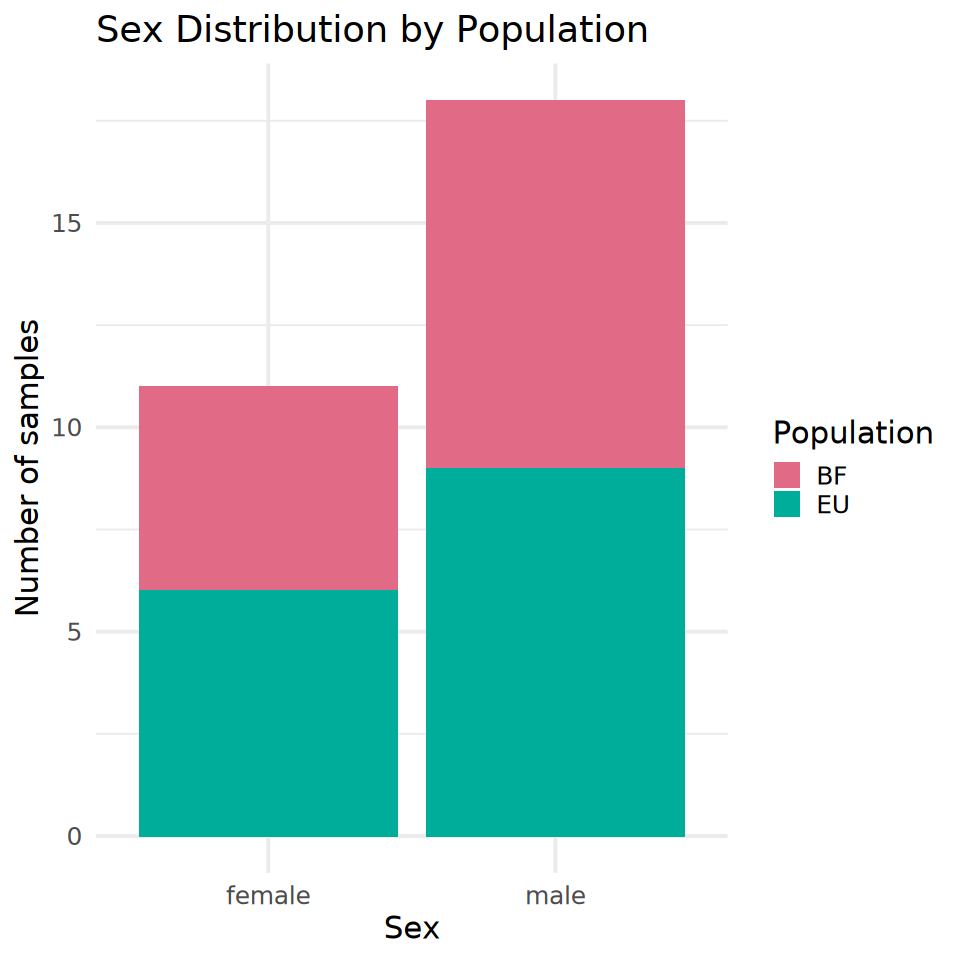

In [43]:
options(repr.plot.width = 8, repr.plot.height = 8)


sample_meta <- as.data.frame(colData(tse))

p <- ggplot(
    sample_meta,
    aes(
        x = sex,
        fill = population_group
    )
) +
    geom_bar(position = "stack") +
    theme_minimal(base_size = 17) +
    labs(
        title = "Sex Distribution by Population",
        x = "Sex",
        y = "Number of samples",
        fill = "Population"
    ) +
    scale_fill_discrete(
        labels = c(
            "BF" = "Burkina Faso",
            "EU" = "Europe"
        )
    ) +
    theme(
        plot.title = element_text(
            hjust = 0.5,
            face = "bold"
        )
    ) + scale_fill_manual(values = population_colors) +
        theme_minimal(base_size = 18) 

p

### Plot Relative Abundances

In [44]:
# Replace original ASV ids with arbitrary, shorter ones for easier visual identification
rowData(tse)$original_ASV_id <- rownames(tse)

rownames(tse) <- paste0(
    "ASV_",
    seq_len(nrow(tse))
)

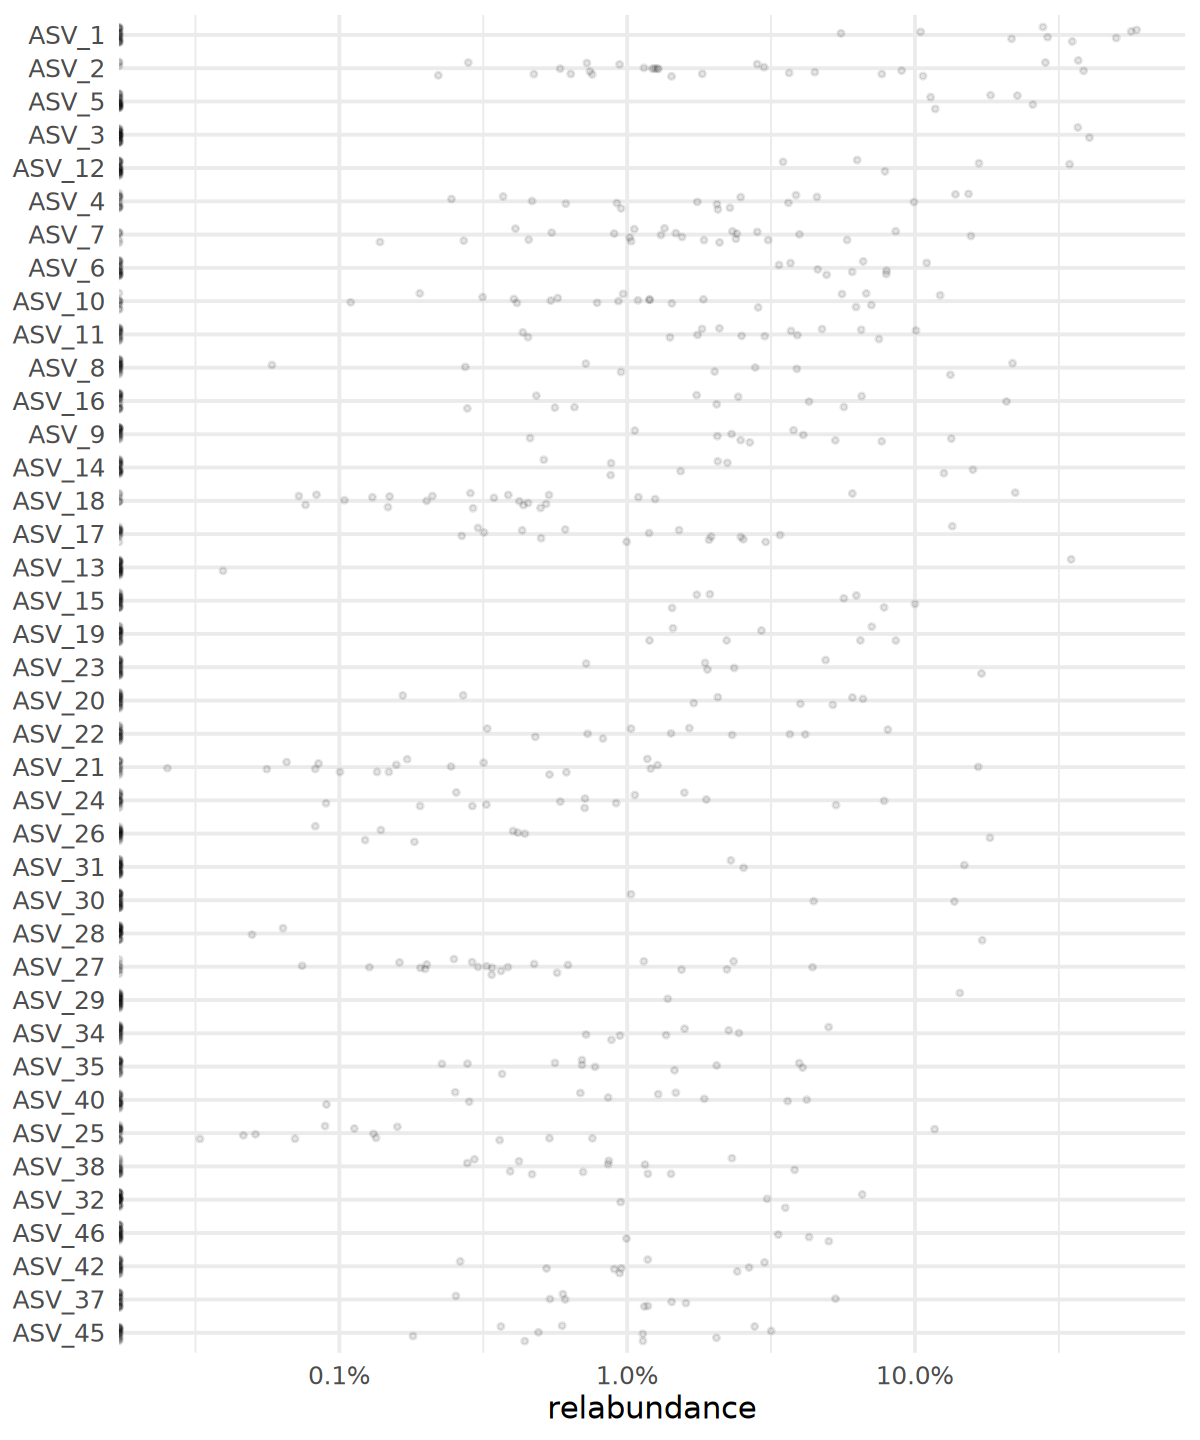

In [45]:
options(repr.plot.width = 10, repr.plot.height = 12)
tse <- transformAssay(tse, method = "relabundance")

plotAbundanceDensity(
    tse,
    layout = "jitter",
    assay.type = "relabundance",
    n = 40, point.size = 1, point.shape = 19,
    point.alpha = 0.1
) +
    scale_x_log10(label = scales::percent) +
        theme_minimal(base_size = 18) 


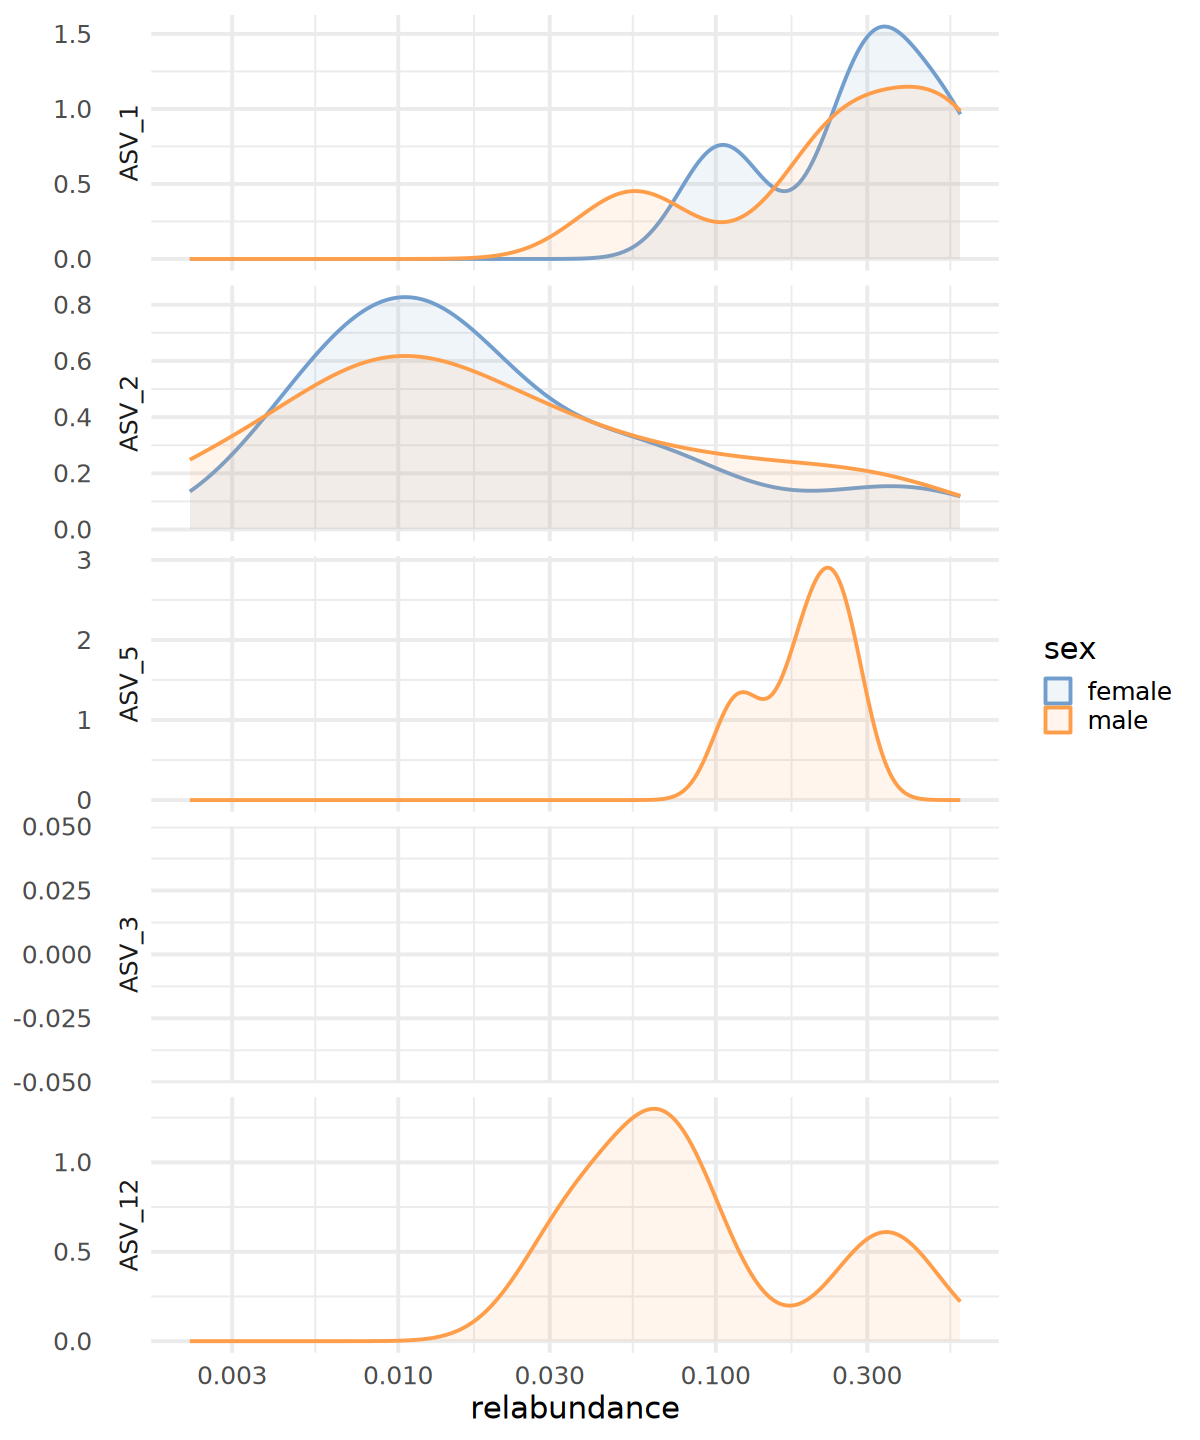

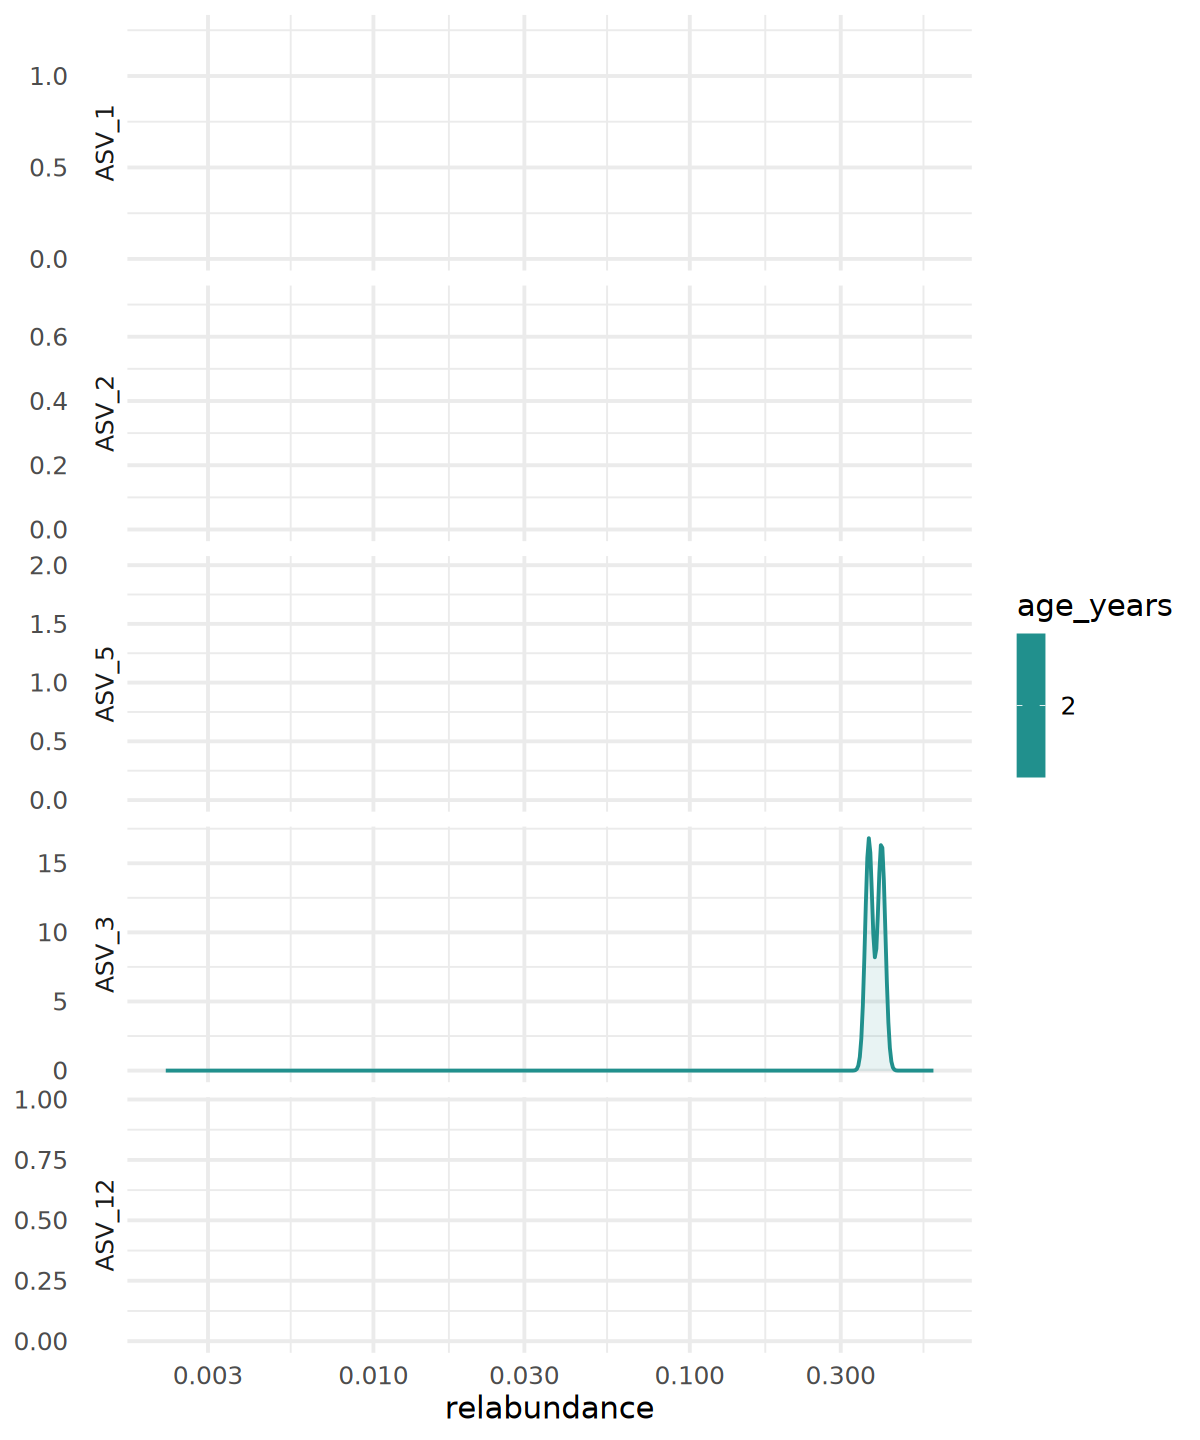

In [46]:
plotAbundanceDensity(
    tse,
    layout = "density",
    assay.type = "relabundance",
    n = 5, colour.by = "sex",
    point.alpha = 0.1
) +
    scale_x_log10() +
        theme_minimal(base_size = 18) 


plotAbundanceDensity(
    tse,
    layout = "density",
    assay.type = "relabundance",
    n = 5, colour.by = "age_years",
    point.alpha = 0.1
) +
    scale_x_log10() +
        theme_minimal(base_size = 18) 

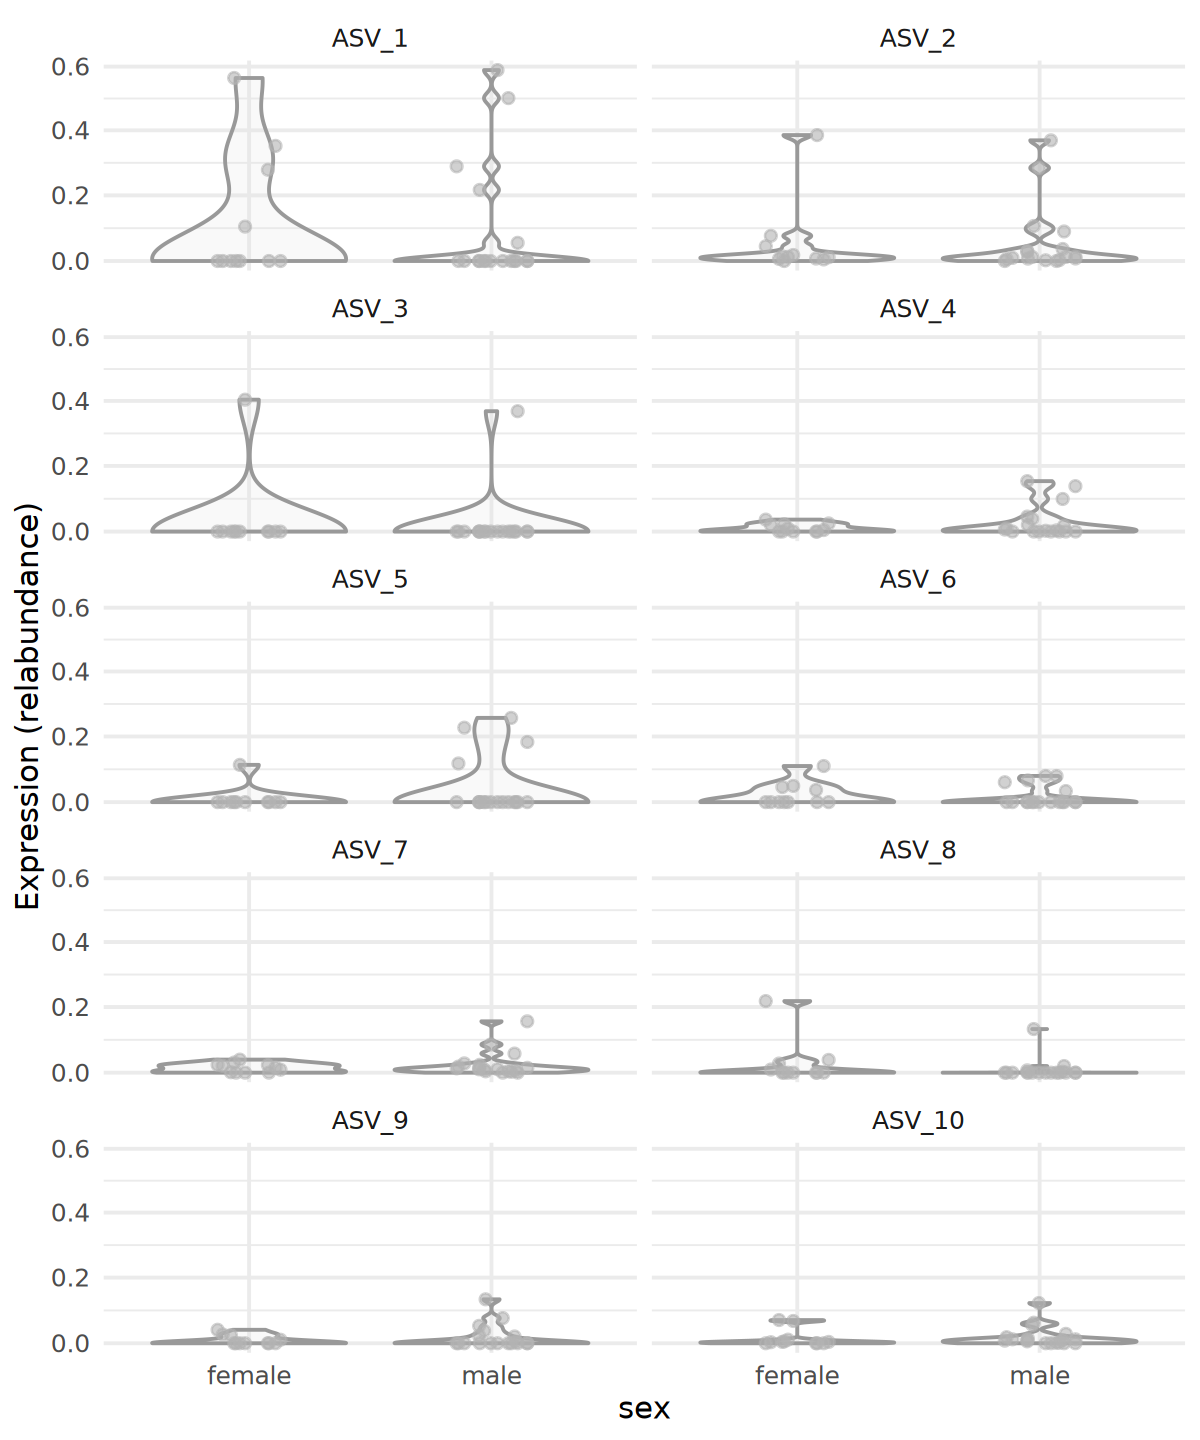

In [47]:
# the native plotExpression()  function from scater does a quasirandom thing to visually disperse the points, but this doesn't 
#    work when there's only one point for a ASV x sex combination
# replacing it with normal jitter

top <- getTop( tse, top = 10L, method = "mean")

p <- plotExpression(tse, features = top,
    x = "sex",
    assay.type = "relabundance",
    point_alpha = 0.6
)

# 
quasirandom_layers <- which(
    sapply(
        p$layers,
        function(x) inherits(x$position, "PositionQuasirandom")
    )
)

for (i in quasirandom_layers) {
    p$layers[[i]]$position <- position_jitter(        width = 0.15,
        height = 0
    )
}

p + scale_y_continuous(trans = scales::pseudo_log_trans(base = 10)) +
        theme_minimal(base_size = 18) 

### Add & Plot Prevalence

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


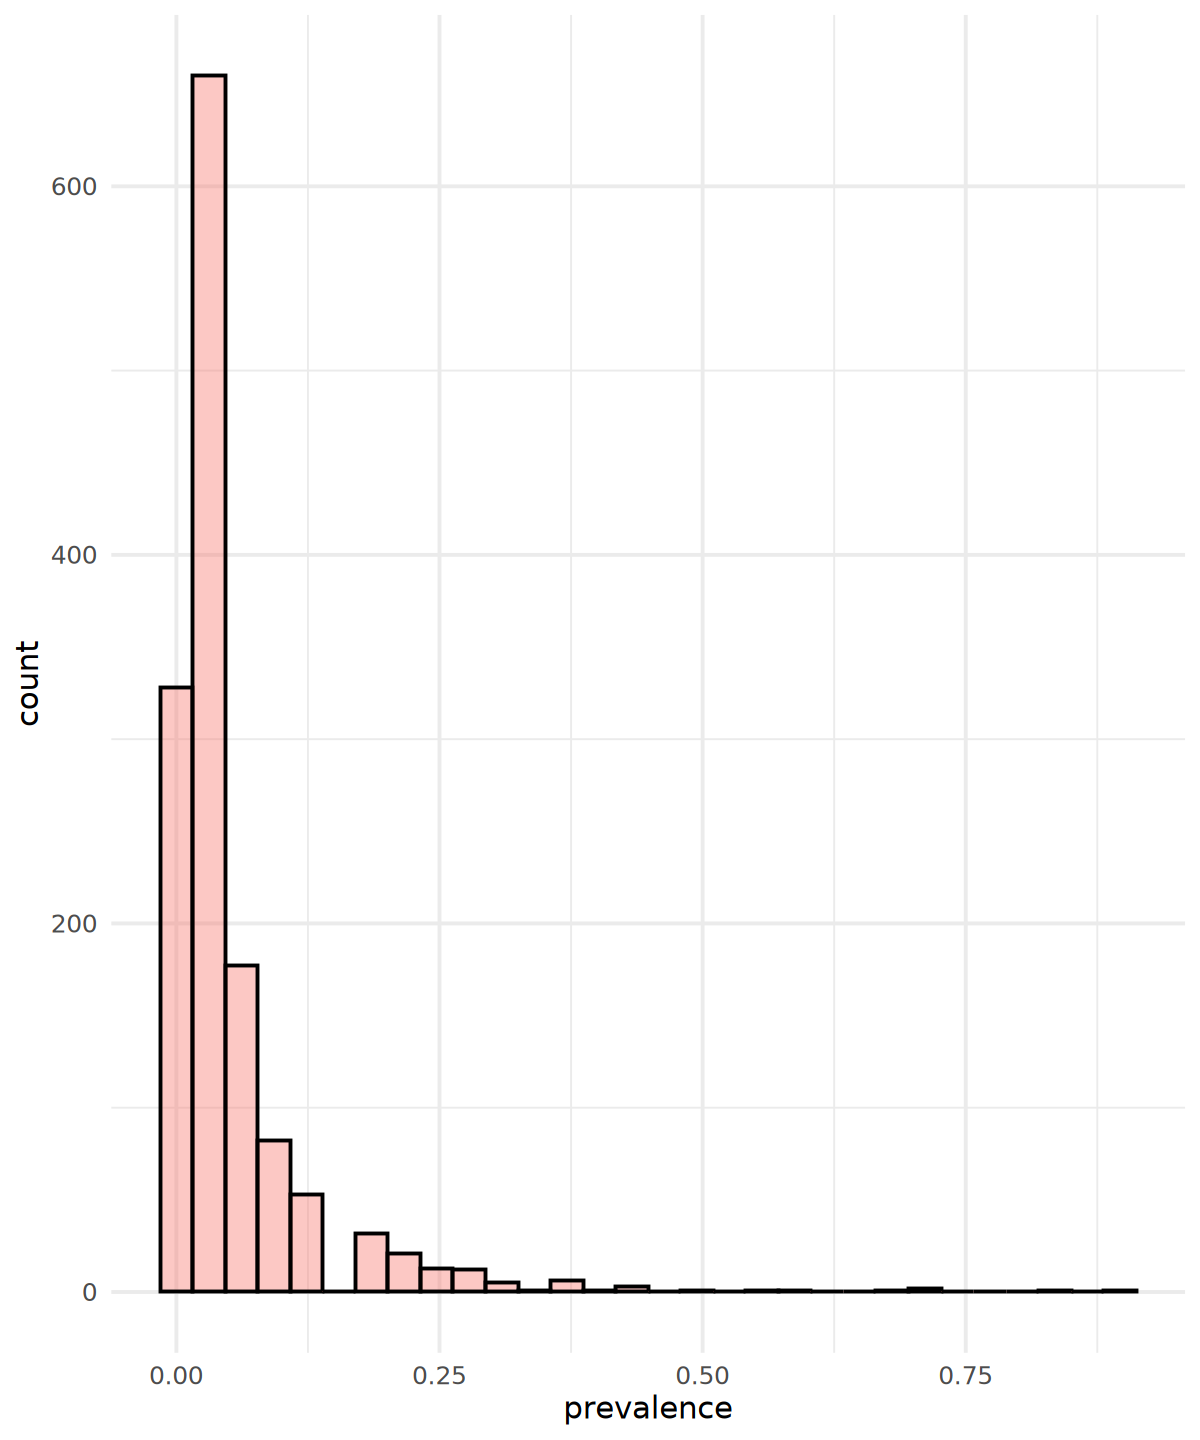

In [48]:
# from tutorial: "Prevalence quantifies the frequency of samples
#    where certain microbes were detected (above a given detection threshold). 
#    Prevalence can be given as sample size (N) or percentage (unit interval). " 



tse <- addPrevalence(tse, detection = 0.1 / 100, as.relative = TRUE)  # 0.01% relative abundance threshold
plotHistogram(tse, row.var = "prevalence") +
        theme_minimal(base_size = 18) 


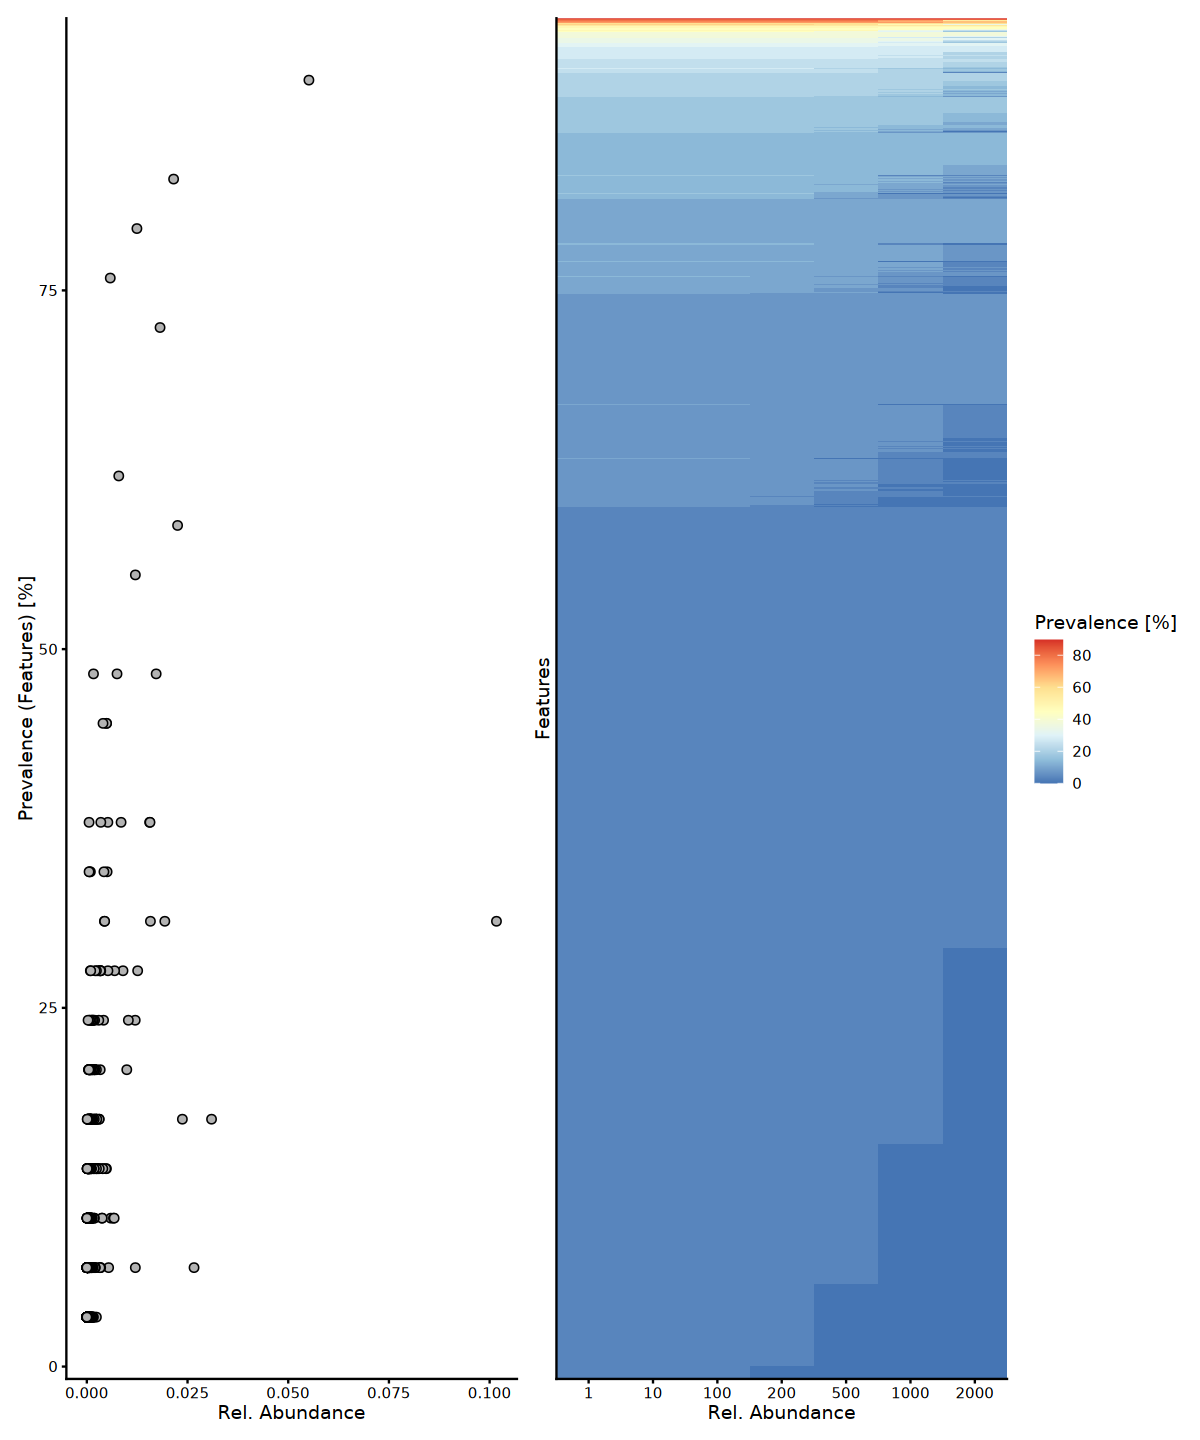

In [49]:
# "Most of the features are present only in a minority of the samples 
# with a specified abundance threshold. Similar conclusion can 
# be made with visualizations generated with the 
# plotPrevalentAbundance() or plotRowPrevalence() functions.



p1 <- plotPrevalentAbundance(tse, as.relative = TRUE)

# Remove y axis text as there are so many features that one cannot read them
p2 <- plotRowPrevalence(tse, as.relative = TRUE) +
    theme(
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank()
    )

p1 + p2

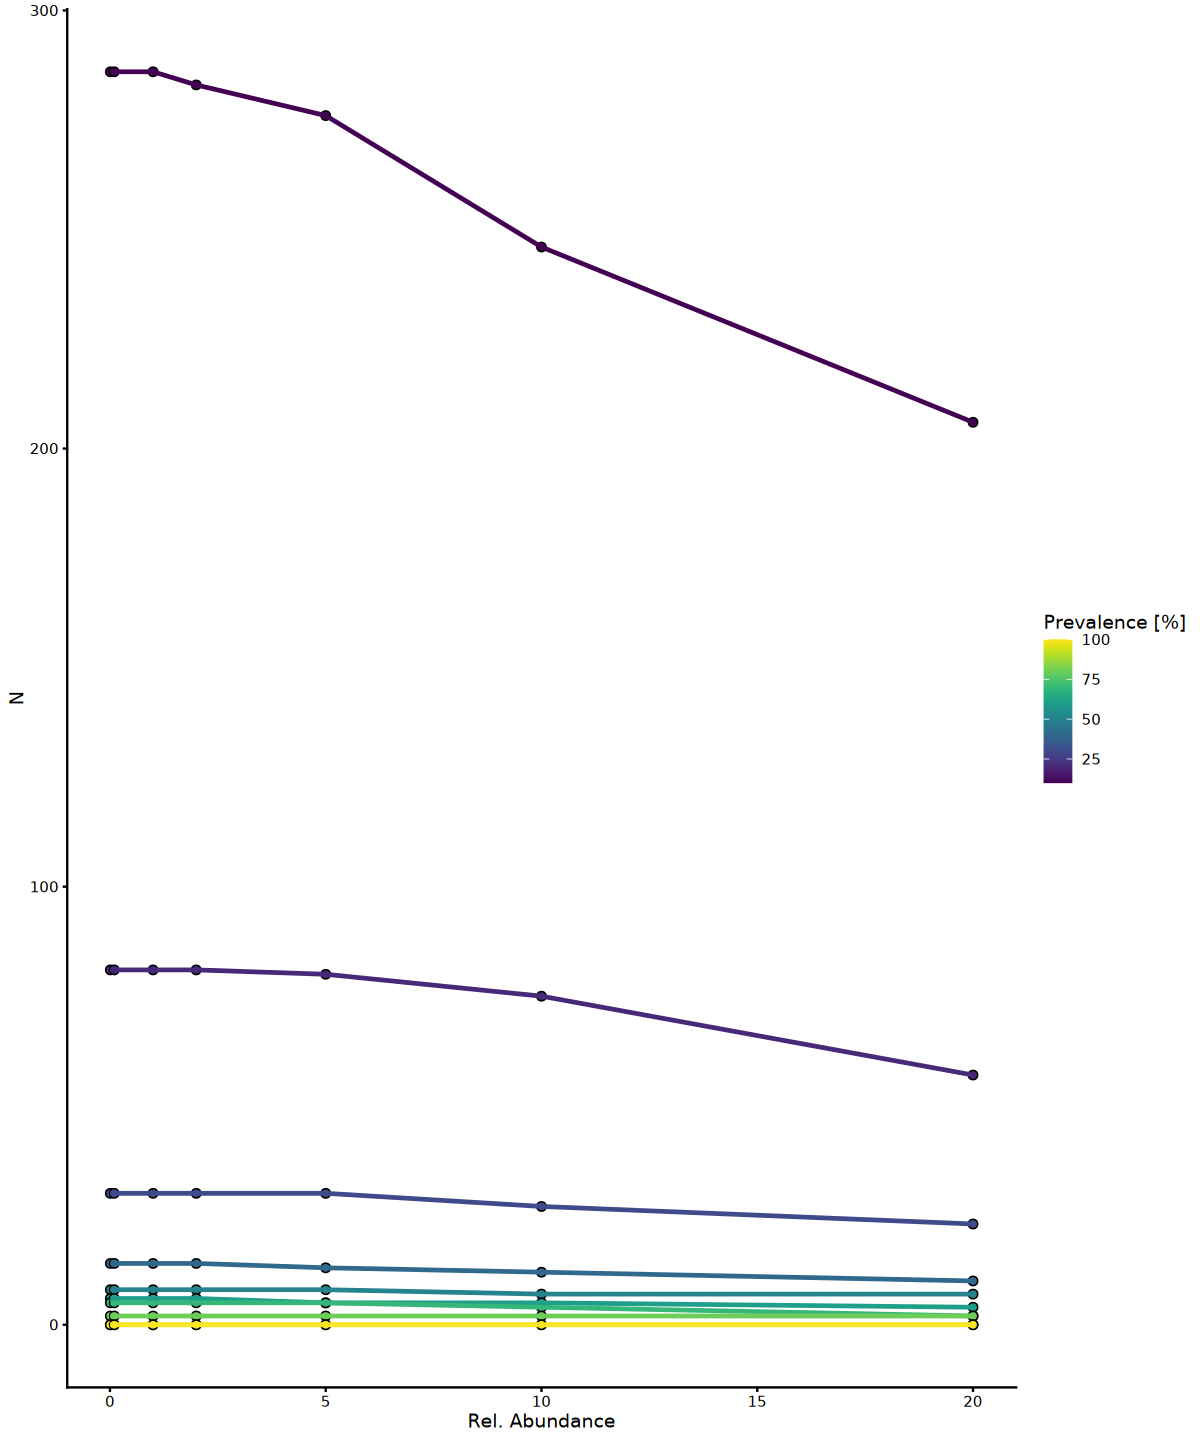

In [50]:
plotPrevalence(tse, as.relative = TRUE)

# "The plot shows the relationship between microbial relative abundance and 
# prevalence across samples. Features with higher prevalence (yellow) 
# tend to have lower relative abundance, while less prevalent 
# features (purple) can still reach higher abundances in some cases.



`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


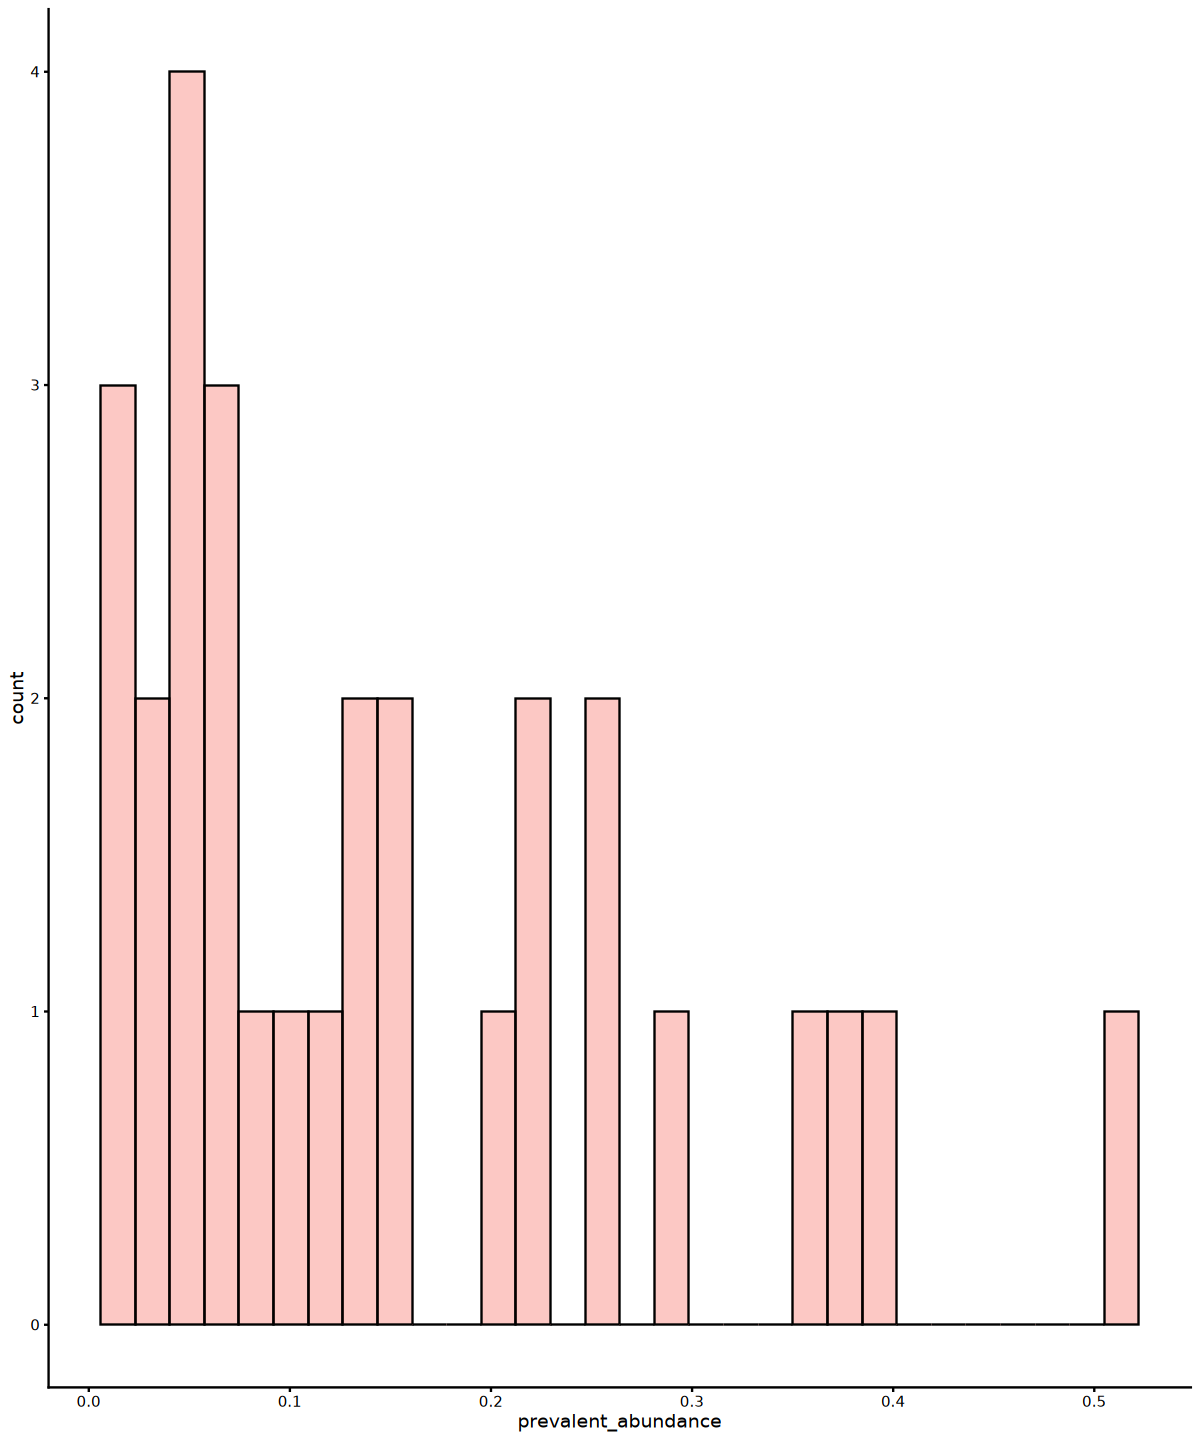

In [51]:
# Calculate the proportion of core taxa
tse <- addPrevalentAbundance(tse,
                             prevalence = 50 / 100, # minimum threshold
                             detection = 0.1 / 100) # minimum thresh. 

# Visualize
plotHistogram(tse, col.var = "prevalent_abundance")

In [53]:
# “What fraction of each sample's microbial community is made up of taxa 
#    that are common across the whole dataset?”


In [54]:
colData(tse)

DataFrame with 29 rows and 27 columns
           group      run_id population_group age_years         sex
     <character> <character>      <character> <numeric> <character>
10BF          BF   ERR011058               BF         6      female
10EU          EU   ERR011059               EU         5        male
11BF          BF   ERR011060               BF         5        male
11EU          EU   ERR011061               EU         5        male
12BF          BF   ERR011062               BF         6        male
...          ...         ...              ...       ...         ...
6EU           EU   ERR011082               EU         6        male
7BF           BF   ERR011083               BF         6        male
8BF           BF   ERR011084               BF         6        male
8EU           EU   ERR011085               EU         5        male
9BF           BF   ERR011086               BF         6        male
     reported_ethnicity     antibiotic_history      delivery_mode
            

In [55]:
# prevalent_abundance is stored in colData()

### Variance Visualization

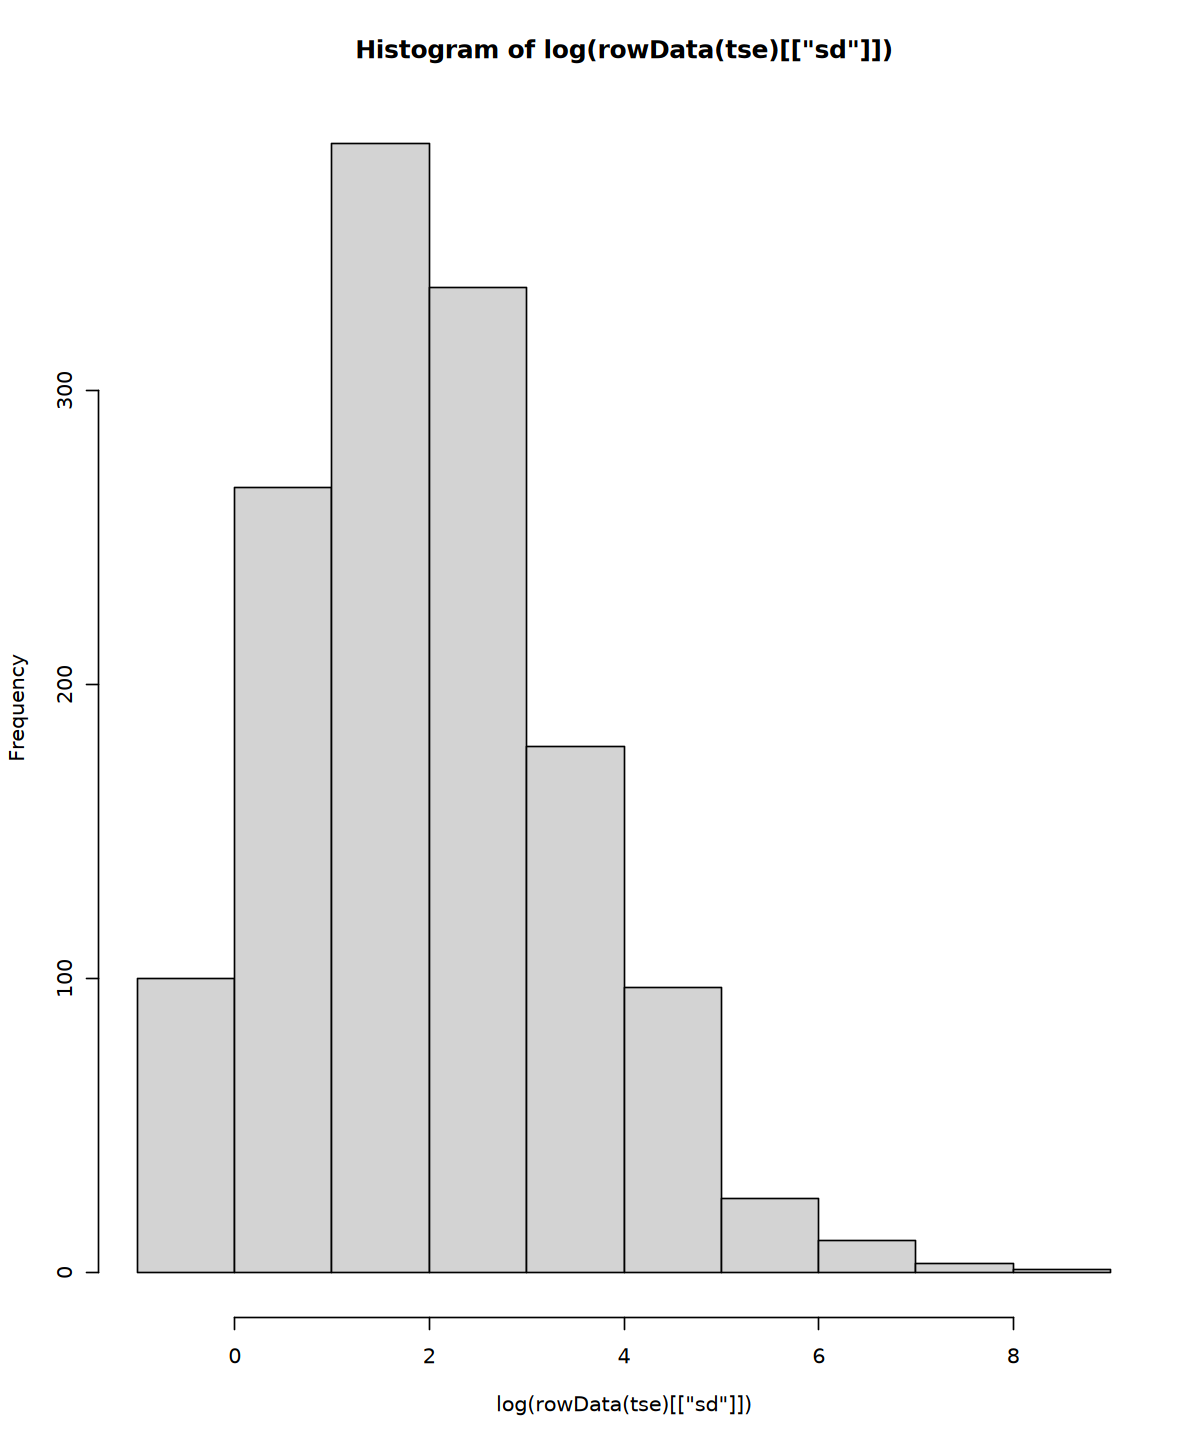

In [56]:
# Calculate stdev
rowData(tse)[["sd"]] <- rowSds(assay(tse, "counts"))
# Plot
hist(log(rowData(tse)[["sd"]]))

In [57]:
selected <- rowData(tse)[["sd"]] > 1
tse_sub <- tse[selected, ]
tse_sub


# A SingleCellExperiment-tibble abstraction: 29 × 28
# Features=1302 | Cells=29 | Assays=counts, relabundance
   .cell group run_id    population_group age_years sex    reported_ethnicity
   <chr> <chr> <chr>     <chr>                <dbl> <chr>  <chr>             
 1 10BF  BF    ERR011058 BF                       6 female black african     
 2 10EU  EU    ERR011059 EU                       5 male   caucasian         
 3 11BF  BF    ERR011060 BF                       5 male   black african     
 4 11EU  EU    ERR011061 EU                       5 male   caucasian         
 5 12BF  BF    ERR011062 BF                       6 male   black african     
 6 12EU  EU    ERR011063 EU                       6 male   caucasian         
 7 13BF  BF    ERR011064 BF                       6 male   black african     
 8 13EU  EU    ERR011065 EU                       5 male   caucasian         
 9 15BF  BF    ERR011066 BF                       6 male   black african     
10 16BF  BF    ERR011067 BF     

In [264]:
# Subset based on prevalence

tse_sub <- subsetByRare(tse, rank = "Genus", prevalence = 0.1, detection = 1)
tse_sub


# A SingleCellExperiment-tibble abstraction: 29 × 28
# Features=58 | Cells=29 | Assays=counts, relabundance
   .cell group run_id    population_group age_years sex    reported_ethnicity
   <chr> <chr> <chr>     <chr>                <dbl> <chr>  <chr>             
 1 10BF  BF    ERR011058 BF                       6 female black african     
 2 10EU  EU    ERR011059 EU                       5 male   caucasian         
 3 11BF  BF    ERR011060 BF                       5 male   black african     
 4 11EU  EU    ERR011061 EU                       5 male   caucasian         
 5 12BF  BF    ERR011062 BF                       6 male   black african     
 6 12EU  EU    ERR011063 EU                       6 male   caucasian         
 7 13BF  BF    ERR011064 BF                       6 male   black african     
 8 13EU  EU    ERR011065 EU                       5 male   caucasian         
 9 15BF  BF    ERR011066 BF                       6 male   black african     
10 16BF  BF    ERR011067 BF       

In [266]:
# rowData(tse_sub)

In [ ]:
# agglomerate by metadata or some other feature
# tse_sub <- agglomerateByVariable(tse, by = "cols", group = "SampleType")
# tse_sub

In [269]:
# Transform
tse_relabund <- transformAssay(tse, method = "relabundance")

# Agglomerate
tse_relabund_prev <- agglomerateByPrevalence(
    tse_relabund,
    assay.type = "relabundance",
    prevalence = 20 / 100,
    detection = 0.1 / 100
)

In [58]:
# rowData(tse_relabund_prev)

### Make Composition Plot

In [60]:
# agglomerate ASVs to phylum
tse_phylum <- agglomerateByRank(
    tse,
    rank = "Phylum",
    na.rm = FALSE
)

# Agglomerate ASVs to genus
tse_genus <- agglomerateByRank(
    tse,
    rank = "Genus",
    na.rm = FALSE
)